# FINANCE 361 — Topic 14: Financial Machine Learning
**Instructor:** Dr. Zicheng (Leo) Xiao  
**University of Auckland — FINANCE 361: Modern Investment Theory**

---

## Learning Objectives
By the end of this notebook you will be able to:
1. Implement a complete ML pipeline (load → split → train → evaluate) in Python using `scikit-learn`
2. Compare five ML models — OLS, Ridge, Decision Tree, GBM, Neural Network — on a real return-prediction task
3. Visualise the bias-variance tradeoff empirically by varying decision tree depth
4. Apply hyperparameter tuning via cross-validation and explain why it matters in finance
5. Reproduce key results from Gu, Kelly & Xiu (2020) at a simplified scale

## 0. Setup & Imports

In [1]:
# Install any missing packages (run once on Colab)
# !pip install scikit-learn pandas numpy matplotlib seaborn yfinance --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Style
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
})

RANDOM_STATE = 0
TRAIN_CUTOFF_YEAR = 2000

print('Setup complete.')

Setup complete.


---
## 1. Load Real Factor Data

We download monthly HXZ q5 factor data directly from `global-q.org`. The dataset contains:
- `R_F` — risk-free rate
- `R_MKT` — market excess return
- `R_ME` — size factor (Small Minus Big)
- `R_IA` — investment factor
- `R_ROE` — profitability factor
- `R_EG` — expected growth factor

**Our task:** predict `R_MKT` in the *next* month using all factors in the *current* month.

In [2]:
URL = ("http://global-q.org/uploads/1/2/2/6/122679606/"
       "q5_factors_monthly_2019a.csv")

df = pd.read_csv(URL)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Date range: {df['year'].min()} – {df['year'].max()}")
df.head()

Shape: (636, 8)
Columns: ['year', 'month', 'R_F', 'R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG']
Date range: 1967 – 2019


,year,month,R_F,R_MKT,R_ME,R_IA,R_ROE,R_EG
0,1967,1,0.3927,8.1603,6.7282,-2.9434,1.8866,-2.2469
1,1967,2,0.3743,0.7202,1.6918,-0.2064,3.5317,2.5812
2,1967,3,0.3693,3.9691,1.9517,-1.6933,1.8876,-1.4789
3,1967,4,0.3344,3.8265,-0.7446,-2.9519,1.0983,-2.2351
4,1967,5,0.3126,-4.2419,2.9132,2.4686,0.5234,0.2749


In [3]:
# Create target: next-month market return
df['R_FWD_MKT'] = df['R_MKT'].shift(-1)

# Drop the last row (NaN target) and any other NaNs
df.dropna(inplace=True)

print(f"Final dataset: {df.shape[0]} monthly observations")

Final dataset: 635 monthly observations


### 📝 Predict-Then-Verify Checkpoint 1
> **Before running the next cell:** The dataset spans from the 1960s to 2019 and we split at year 2000.  
> How many observations do you expect in the training set vs. the test set?  
> Write your estimate here: _____________

Then run the cell and check.

In [4]:
# Train / Test split
FEATURES = ['R_F', 'R_MKT', 'R_ME', 'R_IA', 'R_ROE', 'R_EG']
TARGET   = 'R_FWD_MKT'

D_train = df[df['year'] < TRAIN_CUTOFF_YEAR].copy()
D_test  = df[df['year'] >= TRAIN_CUTOFF_YEAR].copy()

X_train, y_train = D_train[FEATURES], D_train[TARGET]
X_test,  y_test  = D_test[FEATURES],  D_test[TARGET]

print(f"Training observations : {len(X_train):4d}  ({D_train['year'].min()}–{D_train['year'].max()})")
print(f"Test observations     : {len(X_test):4d}  ({D_test['year'].min()}–{D_test['year'].max()})")

Training observations :  396  (1967–1999)
Test observations     :  239  (2000–2019)


---
## 2. Five-Model Horse Race

We fit five models and report **out-of-sample MSE** (lower = better).

### 📝 Predict-Then-Verify Checkpoint 2
> **Before running the next cell:** Rank the five models from best (lowest MSE) to worst.  
> Your prediction: ___  →  ___  →  ___  →  ___  →  ___

Then run and compare.

In [5]:
MODELS = {
    'OLS':       LinearRegression(),
    'Ridge':     Ridge(alpha=2),
    'Tree':      DecisionTreeRegressor(random_state=RANDOM_STATE),
    'GBM':       GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=10),
    'NeuralNet': MLPRegressor(random_state=RANDOM_STATE, early_stopping=True,
                              max_iter=500),
}

results = {}
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    preds  = model.predict(X_test)
    mse    = mean_squared_error(y_test, preds)
    r2     = r2_score(y_test, preds)
    results[name] = {'MSE': round(mse, 3), 'R2': round(r2, 4)}

results_df = pd.DataFrame(results).T.sort_values('MSE')
print(results_df.to_string())

              MSE      R2
GBM        18.411  0.0286
Ridge      19.392 -0.0231
OLS        19.445 -0.0259
NeuralNet  19.819 -0.0456
Tree       37.145 -0.9597


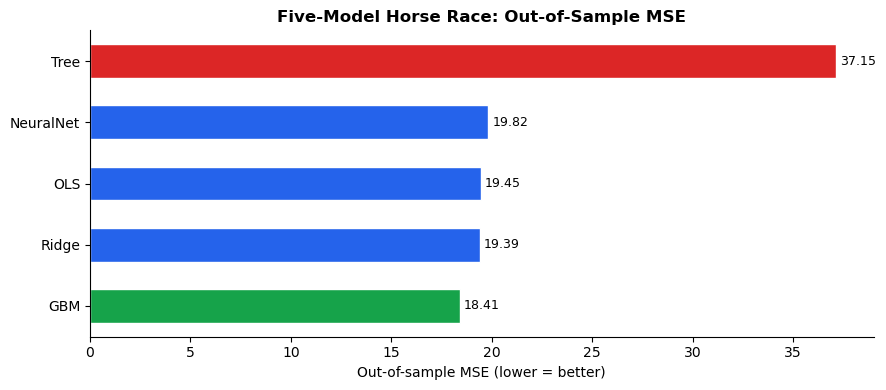

In [6]:
# Visualise
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['#16a34a' if m == 'GBM' else ('#dc2626' if m == 'Tree' else '#2563eb')
          for m in results_df.index]
ax.barh(results_df.index, results_df['MSE'], color=colors, edgecolor='white',
        height=0.55)
ax.set_xlabel('Out-of-sample MSE (lower = better)')
ax.set_title('Five-Model Horse Race: Out-of-Sample MSE', fontweight='bold')

for i, (name, row) in enumerate(results_df.iterrows()):
    ax.text(row['MSE'] + 0.2, i, f"{row['MSE']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 3. The Bias-Variance Tradeoff in Action

Here we vary the `max_depth` of a Decision Tree from 1 to 15 and plot both training and test MSE.  
This empirically demonstrates the **overfitting** regime.

### 📝 Predict-Then-Verify Checkpoint 3
> **Before running:** At what tree depth do you expect the test MSE to be minimised?  
> Your guess: depth = ___

Optimal depth (lowest test MSE): 2  →  test MSE = 18.29


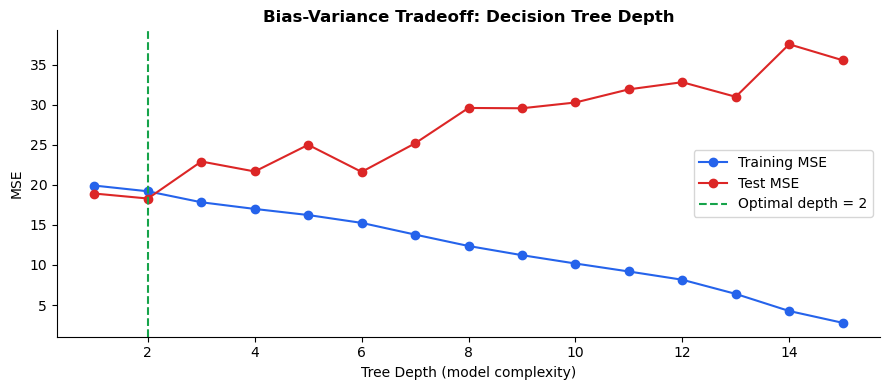

In [13]:
depths = list(range(1, 16))
train_mses, test_mses = [], []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, tree.predict(X_train)))
    test_mses.append(mean_squared_error(y_test,  tree.predict(X_test)))

best_depth = depths[np.argmin(test_mses)]
print(f"Optimal depth (lowest test MSE): {best_depth}  →  test MSE = {min(test_mses):.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depths, train_mses, 'o-', color='#2563eb', label='Training MSE')
ax.plot(depths, test_mses,  'o-', color='#dc2626', label='Test MSE')
ax.axvline(best_depth, color='#16a34a', linestyle='--', linewidth=1.5,
           label=f'Optimal depth = {best_depth}')
ax.set_xlabel('Tree Depth (model complexity)')
ax.set_ylabel('MSE')
ax.set_title('Bias-Variance Tradeoff: Decision Tree Depth', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Fixing the Toy Example: Hyperparameter Tuning

In the toy example, we used `Ridge(alpha=2)` without tuning `alpha`. Here we use `GridSearchCV` to find the best `alpha` on the **training data** using 5-fold cross-validation.

In [8]:
param_grid = {'ridge__alpha': [0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100]}

pipe = Pipeline([
    ('scaler', StandardScaler()),   # standardise inputs — important for Ridge
    ('ridge', Ridge())
])

grid_search = GridSearchCV(
    pipe, param_grid,
    scoring='neg_mean_squared_error',
    cv=5,              # 5-fold cross-validation on training data only
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_alpha = grid_search.best_params_['ridge__alpha']
tuned_mse  = mean_squared_error(y_test, grid_search.predict(X_test))

print(f"Best alpha (CV): {best_alpha}")
print(f"Tuned Ridge test MSE: {tuned_mse:.3f}")
print(f"Naive Ridge(alpha=2) MSE: {results['Ridge']['MSE']}")
print(f"Improvement: {results['Ridge']['MSE'] - tuned_mse:.3f}")

Best alpha (CV): 100
Tuned Ridge test MSE: 19.166
Naive Ridge(alpha=2) MSE: 19.392
Improvement: 0.226


---
## 5. Variable Importance: Which Factors Matter?

One advantage of tree-based methods over linear models is built-in variable importance.
GBM records how much each feature reduces MSE across all splits — this approximates how much each predictor "matters".

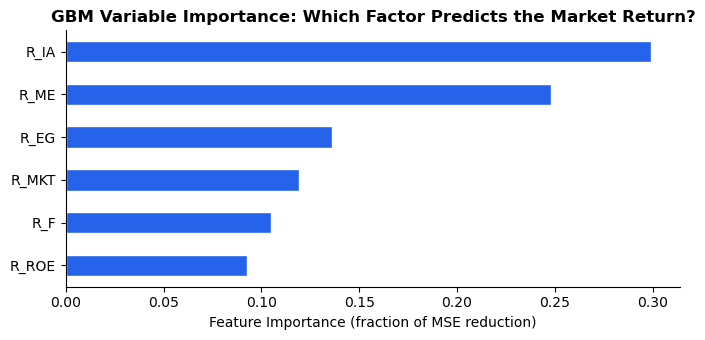


Top predictor: R_IA


In [9]:
# Use a better-tuned GBM
gbm_tuned = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
)
gbm_tuned.fit(X_train, y_train)

importances = pd.Series(gbm_tuned.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
importances.plot.barh(ax=ax, color='#2563eb', edgecolor='white')
ax.set_xlabel('Feature Importance (fraction of MSE reduction)')
ax.set_title('GBM Variable Importance: Which Factor Predicts the Market Return?',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop predictor:", importances.idxmax())

---
## 6. Challenge — The GKX Scale-Up

GKX (2020) use **94 firm-level characteristics** and **individual stock returns** (not aggregate market returns).  
Below we use `yfinance` to download a small sample and replicate the spirit of their approach.

> **Exercise:** Download monthly return data for 10 S&P 500 stocks of your choice. Construct three simple features:  
> - `momentum_1m` = return in month $t$
> - `momentum_12m` = return over months $t-11$ to $t-1$  
> - `volatility_12m` = standard deviation of monthly returns over months $t-11$ to $t-1$  
>  
> Use these features to predict next-month return ($r_{t+1}$). Compare OLS vs. GBM out-of-sample.  
> Does GBM still win? Why or why not?

In [10]:
# !pip install yfinance --quiet

In [11]:
import yfinance as yf

# Choose 10 stocks — feel free to change this list
TICKERS = ['AAPL', 'MSFT', 'JPM', 'JNJ', 'XOM', 'WMT', 'BAC', 'PG', 'CVX', 'HD']

raw = yf.download(TICKERS, start='2000-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True)['Close']

# Monthly returns
rets = raw.pct_change().dropna(how='all')

print(f"Monthly returns shape: {rets.shape}")
rets.head()

[*********************100%***********************]  10 of 10 completed

Monthly returns shape: (299, 10)


Ticker,AAPL,BAC,CVX,HD,JNJ,JPM,MSFT,PG,WMT,XOM
Date,,,,,,,,,,
2000-02-01,0.104820,-0.050323,-0.106876,0.015453,-0.163399,-0.007585,-0.086846,-0.128102,-0.109589,-0.091252
2000-03-01,0.184842,0.139946,0.248125,0.121739,-0.020790,0.094977,0.188812,-0.354196,0.158975,0.041490
2000-04-01,-0.086517,-0.055285,-0.079107,-0.123380,0.174377,-0.172760,-0.343529,0.052863,-0.018679,-0.004006
2000-05-01,-0.322922,0.131377,0.085903,-0.132743,0.084848,0.040930,-0.103047,0.118156,0.040632,0.072406
2000-06-01,0.247024,-0.217228,-0.076025,0.019133,0.142399,-0.074896,0.278721,-0.146616,0.000000,-0.052649


In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Build panel with features for each stock-month
records = []
for ticker in TICKERS:
    s = rets[ticker].dropna()
    for i in range(12, len(s) - 1):
        records.append({
            'ticker':        ticker,
            'date':          s.index[i],
            'mom_1m':        s.iloc[i],
            'mom_12m':       s.iloc[i-11:i+1].sum(),
            'vol_12m':       s.iloc[i-11:i+1].std(),
            'ret_fwd':       s.iloc[i+1],   # target
        })

panel = pd.DataFrame(records).dropna()
panel['year'] = panel['date'].dt.year

print(f"Panel shape: {panel.shape}")

FEAT = ['mom_1m', 'mom_12m', 'vol_12m']
split_year = 2015

train = panel[panel['year'] < split_year]
test  = panel[panel['year'] >= split_year]

for name, model in [('OLS', LinearRegression()),
                    ('GBM', GradientBoostingRegressor(random_state=0, max_depth=2,
                                                     n_estimators=50))]:
    model.fit(train[FEAT], train['ret_fwd'])
    mse = mean_squared_error(test['ret_fwd'], model.predict(test[FEAT]))
    r2  = r2_score(test['ret_fwd'], model.predict(test[FEAT]))
    print(f"{name:6s}  MSE = {mse:.5f}  R² = {r2:.4f}")

Panel shape: (2860, 7)
OLS     MSE = 0.00463  R² = -0.0050
GBM     MSE = 0.00459  R² = 0.0030


---
## 7. Reflect — Explain to Teach

Answer the following **in your own words, without AI assistance**, in 2–3 sentences each:

1. **Bias-variance tradeoff:** Explain the bias-variance tradeoff to a classmate who missed today's lecture. Use the decision tree depth experiment as your concrete example.

2. **Why finance is hard for ML:** Pick *two* of the nine challenges from the lecture notes and explain, in your own words, why they are difficult to overcome.

3. **GKX in one paragraph:** Summarise the key contribution of Gu, Kelly & Xiu (2020) as if writing for the *Financial Times* — a non-technical but financially sophisticated audience.

> *(Double-click this cell to type your answers here.)*

**Your answers:**

1. 

2. 

3.

---
## Extension: Going Further

- **GKX replication (simplified):** Download the 94 characteristics from the `openassetpricing` R package or the [Chen & Zimmermann (2022) open data library](https://www.openassetpricing.com/) and reproduce the GKX horse race on a subset of signals.

- **LLM-based factor construction:** Prompt Claude or GPT-4 to extract forward-guidance language from 10 earnings call transcripts (available on Seeking Alpha). Score each as positive/negative. Does this text score predict next-quarter stock returns?

- **SHAP values:** Install `shap` and compute SHAP importance values for the GBM model above. Are the most important features the same as the built-in `feature_importances_`?

```python
# pip install shap
import shap
explainer = shap.TreeExplainer(gbm_tuned)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=FEATURES)
```